<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-23-April-21-2026/Lecture-23_Molecule-to-PyG-Graph-Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 23 - Molecule to PyG Graph



In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00


Import all basic pacakges

In [2]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# For progress bar
from tqdm.auto import tqdm

tqdm.pandas()

Download dataset

In [3]:
%%bash
wget https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
tar xvf qm9.tar.gz

qm9.sdf
qm9.sdf.csv


--2026-04-21 16:19:35--  https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
Resolving deepchemdata.s3.us-west-1.amazonaws.com (deepchemdata.s3.us-west-1.amazonaws.com)... 16.15.4.31, 52.219.120.169, 16.15.4.158, ...
Connecting to deepchemdata.s3.us-west-1.amazonaws.com (deepchemdata.s3.us-west-1.amazonaws.com)|16.15.4.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53359625 (51M) [application/x-gzip]
Saving to: ‘qm9.tar.gz’

     0K .......... .......... .......... .......... ..........  0% 1.36M 37s
    50K .......... .......... .......... .......... ..........  0% 1.31M 38s
   100K .......... .......... .......... .......... ..........  0%  312M 25s
   150K .......... .......... .......... .......... ..........  0% 1.42M 28s
   200K .......... .......... .......... .......... ..........  0% 56.3M 23s
   250K .......... .......... .......... .......... ..........  0% 75.9M 19s
   300K .......... .......... .......... .......... .......... 

In [4]:
!ls

qm9.sdf  qm9.sdf.csv  qm9.tar.gz  sample_data


In [5]:
!head qm9.sdf

gdb 1	157.7118	157.70997	157.70699	0.	13.21	-0.3877	0.1171	0.5048	35.3641	0.044749	-40.47893	-40.476062	-40.475117	-40.498597	6.469
 OpenBabel06302521273D

  5  4  0  0  0  0  0  0  0  0999 V2000
   -0.0127    1.0858    0.0080 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0022   -0.0060    0.0020 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.0117    1.4638    0.0003 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.5408    1.4475   -0.8766 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.5238    1.4379    0.9064 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  5  1  0  0  0  0


In [6]:
!head qm9.sdf.csv

mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
gdb_1,157.7118,157.70997,157.70699,0,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.47893,-40.476062,-40.475117,-40.498597,6.469,-395.999594594,-398.643290011,-401.014646522,-372.471772148
gdb_2,293.60975,293.54111,191.39397,1.6256,9.46,-0.257,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363363,-278.62027109,-280.399259105,-259.338802047
gdb_3,799.58812,437.90386,282.94545,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087623693,-213.97429391,-215.159658411,-201.407171167
gdb_4,0,35.6100361,35.6100361,0,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501996533,-387.237686427,-389.016046933,-365.800723969
gdb_5,0,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.40937,-93.408425,-93.431246,6.278

Read dataset

In [7]:
molecules = Chem.SDMolSupplier('qm9.sdf', removeHs=False,
                                   sanitize=False)
data = pd.read_csv("qm9.sdf.csv")



In [8]:
data

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,0.127406,-400.633868,-400.628599,-400.627654,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,0.127495,-400.629713,-400.624444,-400.623500,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,0.140458,-380.753918,-380.748619,-380.747675,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,0.152222,-364.720374,-364.714974,-364.714030,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892


In [9]:
targets = data.keys()[1:]
print(targets)

Index(['A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0',
       'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom',
       'g298_atom'],
      dtype='object')


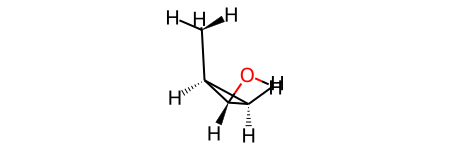

In [11]:
molecules[100]

In [14]:
def visualize_rdkit_mol_2d(mol):
  from rdkit.Chem.Draw import MolToImage
  from rdkit import Chem
  from rdkit.Chem import rdDepictor

  # Attempt to sanitize and kekulize the molecule for better depiction
  # It's good practice to make a copy if you don't want to modify the original supplier object's molecule
  sanitized_mol = Chem.Mol(mol) # Create a copy
  try:
      Chem.SanitizeMol(sanitized_mol)
      # Kekulize for clearer ring depictions, if applicable
      Chem.Kekulize(sanitized_mol)
  except Exception as e:
      print(f"Warning: Could not sanitize or kekulize molecule at index {mol_index}: {e}")
      sanitized_mol = mol # Fallback to original if sanitization fails

  # Compute 2D coordinates for the (potentially) sanitized molecule
  rdDepictor.Compute2DCoords(sanitized_mol)

  # Visualize the molecule
  img = MolToImage(sanitized_mol, size=(300, 300))
  display(img)

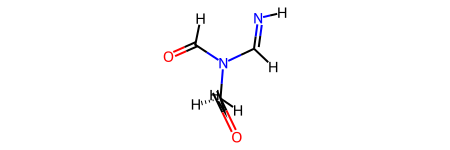

In [17]:
mol_index = 10000
molecules[mol_index]

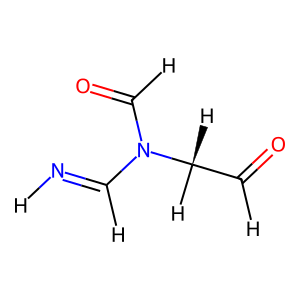

In [18]:

visualize_rdkit_mol_2d(molecules[mol_index])

## RDKit mol to PyG Graph

In [20]:
import torch
from torch_geometric.data import Data

ATOM_FEATURES = {
    "atomic_num":       list(range(1, 9)),
    "degree":           list(range(0, 11)),
    "formal_charge":    [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
    "chiral_tag":       list(range(4)),
    "num_Hs":           list(range(0, 9)),
    "hybridization":    [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo": list(range(6)),
    "is_conjugated": [False, True],
    "is_in_ring":    [False, True],
}


def one_hot(value, choices):
    """One-hot encode a value; unknown → all-zeros."""
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


def atom_features(atom) -> list:
    feats = []
    feats += one_hot(atom.GetAtomicNum(),       ATOM_FEATURES["atomic_num"])
    feats += one_hot(atom.GetDegree(),           ATOM_FEATURES["degree"])
    feats += one_hot(atom.GetFormalCharge(),     ATOM_FEATURES["formal_charge"])
    feats += one_hot(int(atom.GetChiralTag()),   ATOM_FEATURES["chiral_tag"])
    feats += one_hot(atom.GetTotalNumHs(),       ATOM_FEATURES["num_Hs"])
    feats += one_hot(atom.GetHybridization(),    ATOM_FEATURES["hybridization"])
    feats.append(int(atom.GetIsAromatic()))
    feats.append(atom.GetMass() / 100.0)        # scaled mass
    return feats


def bond_features(bond) -> list:
    feats = []
    feats += one_hot(bond.GetBondType(),         BOND_FEATURES["bond_type"])
    feats += one_hot(int(bond.GetStereo()),      BOND_FEATURES["stereo"])
    feats += one_hot(bond.GetIsConjugated(),     BOND_FEATURES["is_conjugated"])
    feats += one_hot(bond.IsInRing(),            BOND_FEATURES["is_in_ring"])
    return feats

def mol_to_graph(mol, y=None):

    if mol is None:
        return None

    # Atom features
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()], dtype=torch.float
    )

    # Bond features (undirected => two directed edges per bond)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, len(bond_features(
            mol.GetBondWithIdx(0)
        ))), dtype=torch.float) if mol.GetNumBonds() > 0 else torch.zeros((0, 14), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data

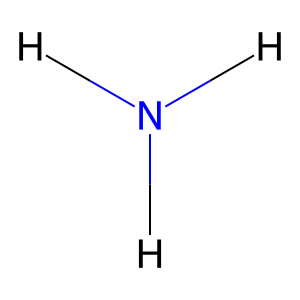

Data(x=[4, 56], edge_index=[2, 6], edge_attr=[6, 18])


In [24]:
mol_index = 1
visualize_rdkit_mol_2d(molecules[mol_index])
g = mol_to_graph(molecules[mol_index])
print(g)

In [26]:
print(g.edge_index)

tensor([[1, 0, 2, 0, 3, 0],
        [0, 1, 0, 2, 0, 3]])


## Visualize Graph

In [27]:
def visualize_graph(mol_graph):
  from torch_geometric.utils import to_networkx
  import networkx as nx
  import matplotlib.pyplot as plt
  import torch

  data_instance = mol_graph

  # Convert the PyG graph to a NetworkX graph
  G = to_networkx(data_instance, to_undirected=True)

  # Define mapping for atomic numbers to element symbols
  # Extended to cover all common atoms in QM9 and within the one-hot encoding range
  atomic_number_map = {
      1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B',
      6: 'C', 7: 'N', 8: 'O', 9: 'F',
  }

  # Prepare node labels (atom types)
  node_labels = {}
  # The length of the one-hot vector for atomic_num is len(ATOM_FEATURES["atomic_num"]) + 1
  atomic_num_choices = ATOM_FEATURES["atomic_num"]
  one_hot_vec_len = len(atomic_num_choices) + 1

  for i, node_features_tensor in enumerate(data_instance.x):
      # Extract the one-hot encoded atomic number part
      atomic_num_one_hot_vector = node_features_tensor[:one_hot_vec_len]

      # Find the index of the '1' in the one-hot vector
      atomic_num_idx = torch.argmax(atomic_num_one_hot_vector).item()

      # Convert the index back to the actual atomic number
      if atomic_num_idx < len(atomic_num_choices):
          atomic_num = atomic_num_choices[atomic_num_idx]
      else:
          # This means the atomic number was not in the choices list (e.g., if one_hot encoded it as 'unknown')
          atomic_num = 0 # Represent as unknown or fallback

      node_labels[i] = atomic_number_map.get(atomic_num, f'Unknown({atomic_num})')

  # Define mapping for edge attributes (bond types)
  # Assuming edge_attr is a one-hot encoding for [single, double, triple, aromatic]
  bond_type_map = {
      0: 'single',
      1: 'double',
      2: 'triple',
      3: 'aromatic'
  }

  # Prepare edge labels
  edge_labels = {}
  # Iterate through the original PyG edge_index and edge_attr to get labels
  # edge_index.t() transposes (2, num_edges) to (num_edges, 2) for easier iteration
  for i, (u, v) in enumerate(data_instance.edge_index.t().tolist()):
      # Get the one-hot encoded attribute vector for the current edge
      attr_vector = data_instance.edge_attr[i]

      # Determine the bond type from the one-hot vector
      # Only process if the vector has a '1' (i.e., it's a valid one-hot)
      if attr_vector.sum() > 0:
          bond_type_idx = torch.argmax(attr_vector).item()
          label = bond_type_map.get(bond_type_idx, f"type_{bond_type_idx}")
      else:
          label = "unknown" # Fallback for unexpected attribute vectors

      # Add the label to the dictionary. NetworkX's draw_networkx_edge_labels
      # will correctly match this label to the undirected edge in G.
      # We'll add it for the (u, v) pair as it appears in edge_index.
      edge_labels[(u, v)] = label


  plt.figure(figsize=(6, 6)) # Make figure slightly larger to accommodate labels
  pos = nx.spring_layout(G, seed=42) # Use a fixed seed for reproducible layout

  # Draw nodes and edges
  nx.draw_networkx(G, pos,
                  labels=node_labels, # Use atom types as node labels
                  node_color='skyblue',
                  node_size=700, # Slightly larger nodes
                  font_size=10,
                  font_weight='bold',
                  width=1.5) # Slightly thicker edges

  # Draw edge labels
  nx.draw_networkx_edge_labels(G, pos,
                                edge_labels=edge_labels,
                                font_color='red',
                                font_size=8)

  plt.title(f"Graph Visualization")
  plt.axis('off') # Hide axes for cleaner look
  plt.show()

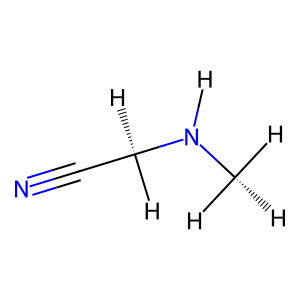

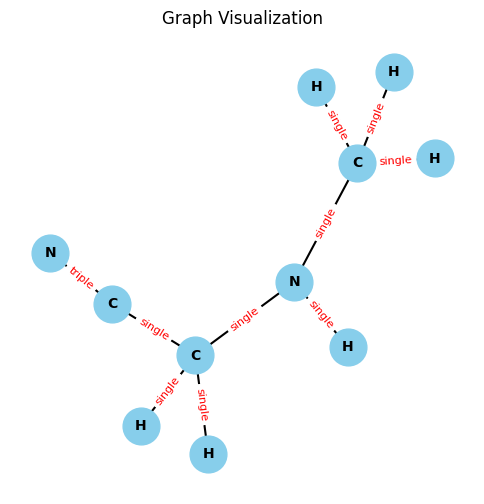

In [81]:
mol_index = 122
visualize_rdkit_mol_2d(molecules[mol_index])

g = mol_to_graph(molecules[mol_index])
visualize_graph(g)

In [40]:
data.iloc[1][targets]

,1
A,293.60975
B,293.54111
C,191.39397
mu,1.6256
alpha,9.46
homo,-0.257
lumo,0.0829
gap,0.3399
r2,26.1563
zpve,0.034358


In [52]:
mol_graphs = []

for i, mol in enumerate(tqdm(molecules)):
    # add molecular properties to the Data object
    g = mol_to_graph(mol, y=data.iloc[i][targets])
    if g:
      mol_graphs.append(g)

  0%|          | 0/133885 [00:00<?, ?it/s]

/tmp/ipykernel_1608/596697622.py:90: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor([y], dtype=torch.float)
[16:45:45] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[16:46:10] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 2
[16:46:22] ERROR: Atom line too short: ' 16  6  1  0  0  0  0' on line 1499176
[16:46:22] ERROR: moving to the beginning of the next molecule
[16:46:22] ERROR: Atom line too short: ' 16  6  1  0  0  0  0' on line 1499186
[16:46:22] ERROR: moving to the beginning of the next molecule
[16:46:22] ERROR: Atom line too short: ' 15  6  1  0  0  0  0' on line 1499196
[16:46:22] ERROR: moving to the beginning of the next molecule
[16:46:22] ERROR: Atom line too short: ' 16  7  1  0  0  0  0' on line 1499206
[16:46:

In [60]:
print(len(molecules))
print(len(mol_graphs))

133885
133824


In [49]:
print(mol_graphs[0].y)
print(data.iloc[0])

tensor([[ 1.5771e+02,  1.5771e+02,  1.5771e+02,  0.0000e+00,  1.3210e+01,
         -3.8770e-01,  1.1710e-01,  5.0480e-01,  3.5364e+01,  4.4749e-02,
         -4.0479e+01, -4.0476e+01, -4.0475e+01, -4.0499e+01,  6.4690e+00,
         -3.9600e+02, -3.9864e+02, -4.0101e+02, -3.7247e+02]])
mol_id            gdb_1
A              157.7118
B             157.70997
C             157.70699
mu                  0.0
alpha             13.21
homo            -0.3877
lumo             0.1171
gap              0.5048
r2              35.3641
zpve           0.044749
u0            -40.47893
u298         -40.476062
h298         -40.475117
g298         -40.498597
cv                6.469
u0_atom     -395.999595
u298_atom    -398.64329
h298_atom   -401.014647
g298_atom   -372.471772
Name: 0, dtype: object


In [53]:
indices = [i for i, g in enumerate(mol_graphs) if g is None]
print(indices)

[]


In [57]:
# check if all values in a torch tensor are zero
indices = [i for i, g in enumerate(mol_graphs) if torch.all(g.x == 0).item()]
print(indices)

[]


In [61]:
# Save mol_graphs to file
from torch_geometric.data import InMemoryDataset

file = 'processed_mol_graph_data.pt'

InMemoryDataset.save(mol_graphs, file)

In [63]:
!ls -lh *.pt

-rw-r--r-- 1 root root 946M Apr 21 16:56 processed_mol_graph_data.pt


In [69]:
file = 'processed_mol_graph_data.pt'
mol_graphs_from_file = InMemoryDataset.load(file)

TypeError: InMemoryDataset.load() missing 1 required positional argument: 'path'

In [70]:
# saving to file using Python pickle
import pickle

with open("processed_mol_graph_data.pkl", "wb") as f:  # 'wb' means write binary
    pickle.dump(mol_graphs, f)




In [71]:
!ls -lh *.pkl

-rw-r--r-- 1 root root 1.1G Apr 21 17:01 processed_mol_graph_data.pkl


In [72]:
with open("processed_mol_graph_data.pkl", "rb") as f:  # 'rb' means read binary
    mol_graphs_from_file = pickle.load(f)

In [78]:
idx=100
print(mol_graphs_from_file[idx].y)
print(mol_graphs[idx].y)

tensor([[ 7.3700e+00,  4.7866e+00,  3.5312e+00,  1.3092e+00,  4.5840e+01,
         -2.5180e-01,  8.2200e-02,  3.3400e-01,  4.1830e+02,  1.1383e-01,
         -2.3233e+02, -2.3232e+02, -2.3232e+02, -2.3236e+02,  2.0702e+01,
         -1.1767e+03, -1.1847e+03, -1.1918e+03, -1.0951e+03]])
tensor([[ 7.3700e+00,  4.7866e+00,  3.5312e+00,  1.3092e+00,  4.5840e+01,
         -2.5180e-01,  8.2200e-02,  3.3400e-01,  4.1830e+02,  1.1383e-01,
         -2.3233e+02, -2.3232e+02, -2.3232e+02, -2.3236e+02,  2.0702e+01,
         -1.1767e+03, -1.1847e+03, -1.1918e+03, -1.0951e+03]])
